In [ ]:
import pandas as pd
shah_alam = pd.read_csv('D:\Problems\Dataset_Practice\Shah_Alam_Data_Analysis\House_Data.csv', sep = ',')
shah_alam['Name'] = shah_alam['Name'].str.replace('SHAH ALAM, SELANGOR|SHAH ALAM', '', regex=True, case=False).str.strip()

shah_alam['Tenure_Class'] = shah_alam['Tenure_Type'].str.extract(r'(FREEHOLD,?\s*LEASEHOLD|FREEHOLD|LEASEHOLD)', flags=2)[0]
shah_alam['Tenure_Type'] = shah_alam['Tenure_Type'].str.replace(r'FREEHOLD,?\s*LEASEHOLD|FREEHOLD|LEASEHOLD', '', regex=True, case=False).str.strip()
shah_alam['Tenure_Type'] = shah_alam['Tenure_Type'].str.replace(r'^,\s*|,\s*$', '', regex=True).str.strip()
shah_alam['Name'] = shah_alam['Name'].str.replace(',','', regex=True).str.strip()
shah_alam['Filed_Transactions'] = shah_alam['Filed_Transactions'].str.replace(r'Transactions|Transaction', '', regex=True).str.strip().astype('int')
shah_alam['Median_Price'] = shah_alam['Median_Price'].str.replace(',','').str.strip().astype('int')
shah_alam['Median_Price_Psf'] = shah_alam['Median_Price_Psf'].str.replace(',','').str.strip().astype('int')

column_to_move = shah_alam.pop('Tenure_Class')
shah_alam.insert(1, 'Tenure_Class', column_to_move)
shah_alam.head(10)



,Name,Tenure_Class,Tenure_Type,Median_Price_Psf,Median_Price,Filed_Transactions
0,ELMINA WEST,FREEHOLD,"SEMI-D, TERRACE HOUSE",692,1184888,170
1,ALAM IMPIAN,FREEHOLD,"CLUSTER HOUSE, SEMI-D, TERRACE HOUSE",633,920400,90
2,BUKIT JELUTONG,FREEHOLD,"BUNGALOW, CLUSTER HOUSE, SEMI-D, TERRACE HOUSE",458,1085000,71
3,SEKSYEN 30,"FREEHOLD, LEASEHOLD","BUNGALOW, SEMI-D, TERRACE HOUSE",339,570000,71
4,KOTA KEMUNING,"FREEHOLD, LEASEHOLD","SEMI-D, TERRACE HOUSE",476,900000,56
5,SEKSYEN 29,"FREEHOLD, LEASEHOLD","SEMI-D, TERRACE HOUSE",431,623500,48
6,SEKSYEN 7,LEASEHOLD,"BUNGALOW, CLUSTER HOUSE, SEMI-D, TERRACE HOUSE...",501,700000,35
7,ELMINA EAST,FREEHOLD,"SEMI-D, TERRACE HOUSE",537,870000,33
8,TAMAN SRI MUDA,"FREEHOLD, LEASEHOLD",TERRACE HOUSE,324,330000,29
9,SEKSYEN 32,FREEHOLD,"SEMI-D, TERRACE HOUSE",354,480500,28


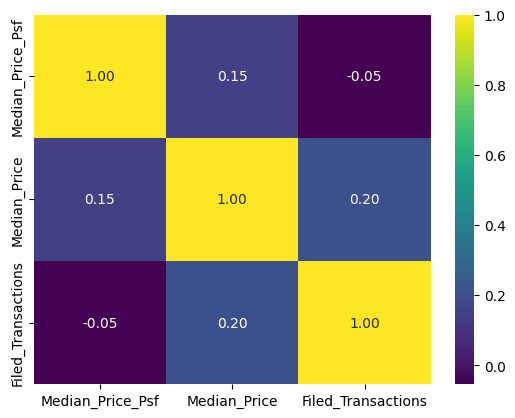

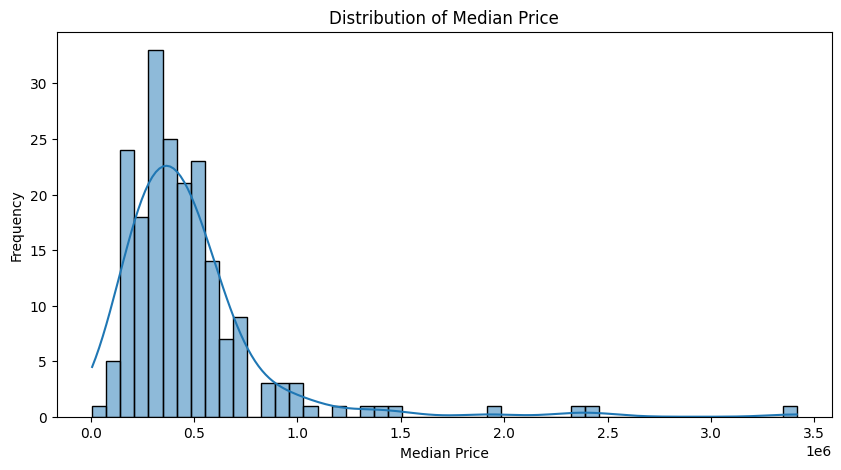

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

subset = shah_alam[['Median_Price_Psf','Median_Price','Filed_Transactions']]
fig = sns.heatmap(subset.corr(), cmap = 'viridis', fmt = '.2f', annot = True)

plt.figure(figsize=(10, 5))
sns.histplot(shah_alam['Median_Price'], bins=50, kde=True)
plt.title('Distribution of Median Price')
plt.xlabel('Median Price')
plt.ylabel('Frequency')
plt.show()


px.scatter(shah_alam, x='Median_Price_Psf', y='Median_Price', 
           labels=dict(x="Price per Square Foot", y="Median Price"),
           title='Median Price vs PSF')